# DATA266 Lab 1 — Task 3: CycleGAN Monet <-> Photo (Khushi)
**Team PAIR_01** · Khushi Donda · independent CycleGAN implementation and evaluation

This notebook **loads the trained model and the stored evaluation artifacts**; it does not retrain. It shows the selected checkpoint (`epoch_28.pt`, which is **completed epoch 29** under zero-based checkpoint naming), re-generates sample translations from it, and presents the verified metrics, human audit, training curves, efficiency and Kaggle evidence.

## 1. Reproducibility seed

In [1]:
import sys, os, json, hashlib, inspect
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "task3_gan" / "khushi").exists())
K = REPO / "task3_gan" / "khushi"
sys.path.insert(0, str(K / "src"))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from PIL import Image
from utils import set_global_seed, sha256_file

SEED = 42
set_global_seed(SEED)
print("seed:", SEED, "| repo-relative root:", REPO.name, "| task folder:", K.relative_to(REPO))

seed: 42 | repo-relative root: DATA266-Lab1-Khushi-Dipin | task folder: task3_gan/khushi


## 2. Imports / environment

In [2]:
import torchvision, platform
print("python", platform.python_version(), "| torch", torch.__version__, "| torchvision", torchvision.__version__)
print("numpy", np.__version__, "| pandas", pd.__version__)
print("device used here:", "cpu (deterministic evaluation)")
print("training hardware (raw log / manifest): NVIDIA GeForce RTX 4090, FP32")
print("environment record:", (K / "outputs/final_eval_epoch029/environment.txt").relative_to(REPO))

python 3.11.16 | torch 2.14.0 | torchvision 0.29.0
numpy 2.4.6 | pandas 3.0.6
device used here: cpu (deterministic evaluation)
training hardware (raw log / manifest): NVIDIA GeForce RTX 4090, FP32
environment record: task3_gan/khushi/outputs/final_eval_epoch029/environment.txt


## 3. Dataset configuration
The dataset is intentionally not stored in Git (see the README for the download link). Point `DATA266_DATA_DIR` at the folder containing `monet_jpg/` and `photo_jpg/`; the default is `task3_gan/data/`.

In [3]:
from dataset import list_images
DATA = Path(os.environ.get("DATA266_DATA_DIR", REPO / "task3_gan" / "data"))
HAVE_DATA = (DATA / "monet_jpg").is_dir() and (DATA / "photo_jpg").is_dir()
if HAVE_DATA:
    monet, photo = list_images(DATA / "monet_jpg"), list_images(DATA / "photo_jpg")
    sizes = {Image.open(p).size for p in monet[:50] + photo[:50]}
    print(f"Monet images: {len(monet)} | photo images: {len(photo)} | sampled image sizes: {sizes}")
    print("A = Monet (all 300 sorted), B = photo (first 300 sorted are used for evaluation)")
else:
    print("dataset folder not found - sample generation below is skipped and stored outputs are shown instead")

Monet images: 300 | photo images: 7038 | sampled image sizes: {(256, 256)}
A = Monet (all 300 sorted), B = photo (first 300 sorted are used for evaluation)


## 4. Architecture definition

In [4]:
import models
print(inspect.getsource(models.ResNetGenerator))
print(inspect.getsource(models.PatchDiscriminator))

class ResNetGenerator(nn.Module):
    """ResNet-9 CycleGAN generator.

    c7s1-64 -> d128 -> d256 -> 9x ResidualBlock(256) -> u128 -> u64 -> c7s1-3(Tanh)

    Reflection padding throughout the c7s1 and residual-block convolutions;
    2 stride-2 convolutions for downsampling; 2 stride-2 ConvTranspose2d
    layers for upsampling; InstanceNorm after every conv (bias kept in
    conv layers immediately followed by InstanceNorm, per the standard
    CycleGAN convention); Tanh output activation so the output range is
    [-1, 1], matching the [-1, 1]-normalized input convention.
    """

    def __init__(self, in_channels=3, out_channels=3, base_filters=64, num_residual_blocks=9):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, base_filters, kernel_size=7, bias=True),
            nn.InstanceNorm2d(base_filters, affine=False),
            nn.ReLU(inplace=True),
        ]

        # 2 stride-2 downsampling convolutions: 64 

## 5. Hyperparameters

In [5]:
cfg = json.load(open(K / "configs" / "task3_config.json"))
t = cfg["training"]
rows = [
    ("seed / image size / load size", f'{cfg["seed"]} / {cfg["image_size"]} / {t["augmentation"]["resize"]}'),
    ("generator", "ResNet-9, reflection padding, InstanceNorm, ReLU, Tanh output"),
    ("discriminator", "70x70 PatchGAN, InstanceNorm, raw output (no sigmoid), 30x30 patch map"),
    ("GAN objective", t["gan_objective"] + " (MSE)"),
    ("lambda_cycle / lambda_identity", f'{t["cycle_consistency_weight"]} / {t["identity_loss_weight"]}'),
    ("optimizer", f'{t["optimizer"]}, lr {t["learning_rate"]}, betas ({t["beta1"]}, {t["beta2"]})'),
    ("batch size / replay pool", f'{t["batch_size"]} / {t["replay_buffer"]["size_per_domain"]}'),
    ("augmentation", "resize 286 -> random crop 256 -> random horizontal flip"),
    ("steps per epoch", t["steps_per_epoch"]),
    ("planned epochs / trained", f'{t["epochs"]} planned (constant lr 1-100, linear decay 101-200) / 40 trained, stopped before the decay phase'),
]
pd.DataFrame(rows, columns=["hyperparameter", "value"]).style.hide(axis="index")

hyperparameter,value
seed / image size / load size,42 / 256 / 286
generator,"ResNet-9, reflection padding, InstanceNorm, ReLU, Tanh output"
discriminator,"70x70 PatchGAN, InstanceNorm, raw output (no sigmoid), 30x30 patch map"
GAN objective,LSGAN (MSE)
lambda_cycle / lambda_identity,10 / 5
optimizer,"Adam, lr 0.0002, betas (0.5, 0.999)"
batch size / replay pool,1 / 50
augmentation,resize 286 -> random crop 256 -> random horizontal flip
steps per epoch,7038
planned epochs / trained,"200 planned (constant lr 1-100, linear decay 101-200) / 40 trained, stopped before the decay phase"


## 6. Checkpoint loading and 7. SHA-256 verification

In [6]:
CKPT = K / "checkpoints" / "task3_khushi_prod_20260930_154246" / "epoch_28.pt"
EXPECTED_SHA = "d3124ab24a6f2201a03673cde5a416d04c78dd44985a3c7d590c48efc7e89d3c"
assert CKPT.exists(), "epoch_28.pt not found (it is distributed with the Canvas package, not through Git)"
sha = sha256_file(CKPT)
print("file:", CKPT.relative_to(REPO), "| size:", f"{CKPT.stat().st_size:,} bytes")
print("SHA-256:", sha)
assert sha == EXPECTED_SHA
print("SHA-256 matches the value recorded in the raw training log and the manifest: OK")

file: task3_gan/khushi/checkpoints/task3_khushi_prod_20260930_154246/epoch_28.pt | size: 339,592,307 bytes
SHA-256: d3124ab24a6f2201a03673cde5a416d04c78dd44985a3c7d590c48efc7e89d3c
SHA-256 matches the value recorded in the raw training log and the manifest: OK


## 8. Model parameter counts (strict state-dict load)

In [7]:
from models import build_generator, build_discriminator, count_parameters
ck = torch.load(CKPT, map_location="cpu", weights_only=False)
nets = {"G_A2B": build_generator(), "G_B2A": build_generator(), "D_A": build_discriminator(), "D_B": build_discriminator()}
total = 0
for n, m in nets.items():
    r = m.load_state_dict(ck["model_state_dicts"][n], strict=True)
    p = count_parameters(m); total += p
    print(f"{n}: {p:>10,} parameters  | {r}")
print(f"total: {total:,}")
print("stored epoch (0-indexed):", ck["epoch"], "-> completed epoch", ck["epoch"] + 1, "| global_step:", ck["global_step"], "= 29 x 7038 =", 29 * 7038)
print("optimizer states:", list(ck["optimizer_state_dicts"]), "| scheduler states:", list(ck["scheduler_state_dicts"]))
assert total == 28285832 and ck["global_step"] == 204102

G_A2B: 11,378,179 parameters  | <All keys matched successfully>
G_B2A: 11,378,179 parameters  | <All keys matched successfully>
D_A:  2,764,737 parameters  | <All keys matched successfully>
D_B:  2,764,737 parameters  | <All keys matched successfully>
total: 28,285,832
stored epoch (0-indexed): 28 -> completed epoch 29 | global_step: 204102 = 29 x 7038 = 204102
optimizer states: ['G', 'D_A', 'D_B'] | scheduler states: ['G', 'D_A', 'D_B']


## 9. Sample translations generated from the checkpoint (eval mode, no_grad, deterministic)

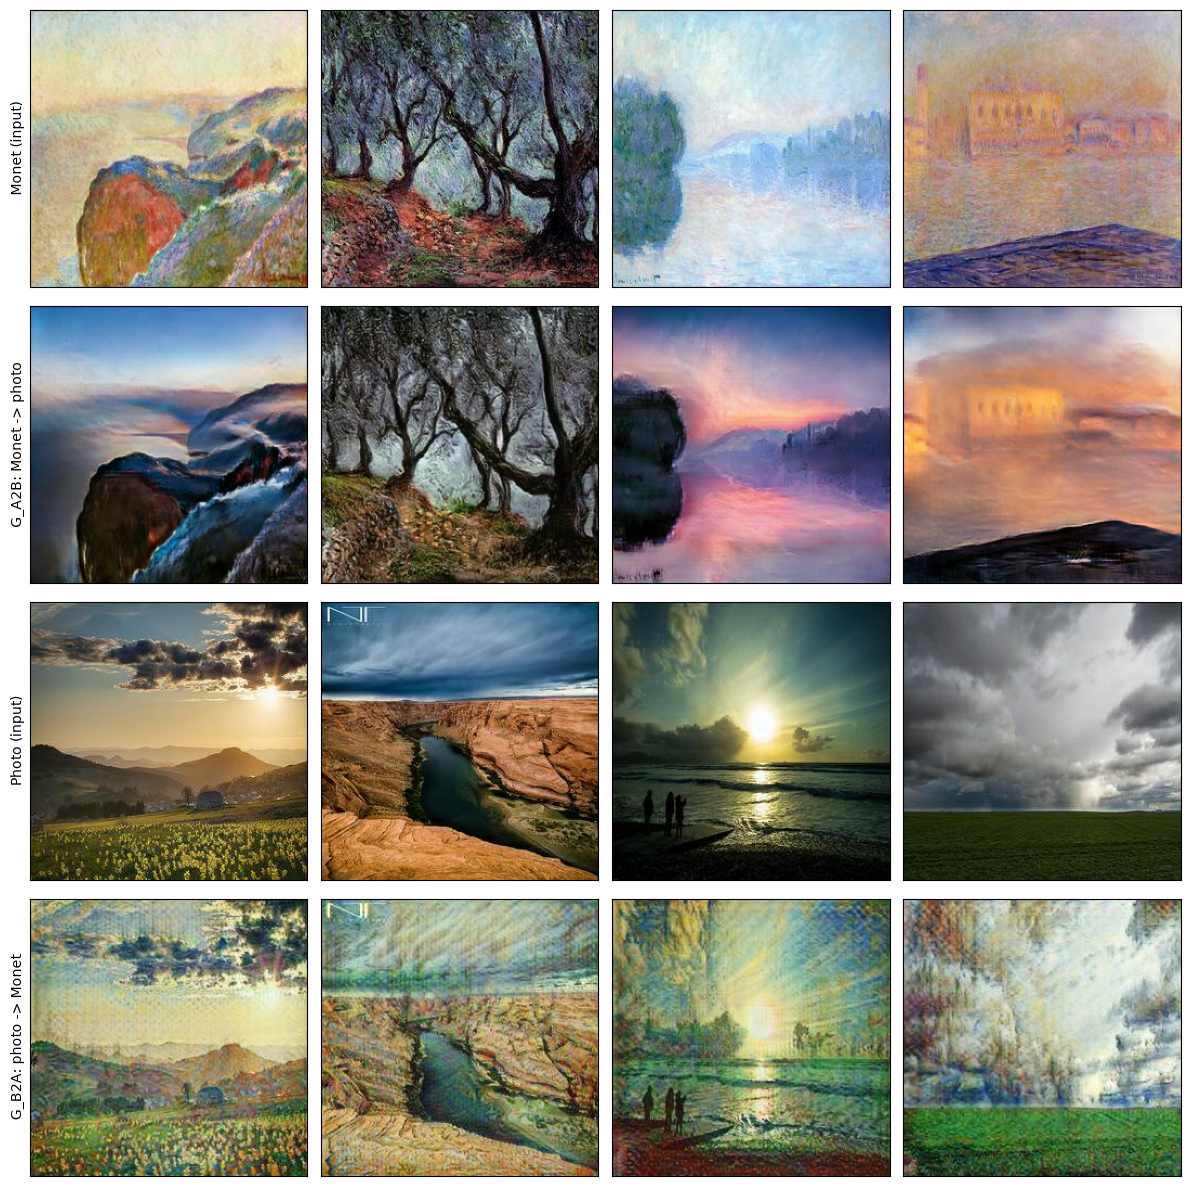

size: (256, 256) mode: RGB | mean |diff| vs stored JPEG q95 prediction: 1.779 gray levels


In [8]:
from generate import _load_input_tensor, denormalize_to_image
for m in nets.values(): m.eval()

def translate(g, path):
    with torch.no_grad():
        x = _load_input_tensor(path, 256, "cpu"); y = g(x)
    assert torch.isfinite(y).all()
    return denormalize_to_image(y[0])

if HAVE_DATA:
    ins_a, ins_b = monet[:4], photo[:4]
    outs_a = [translate(nets["G_A2B"], p) for p in ins_a]
    outs_b = [translate(nets["G_B2A"], p) for p in ins_b]
    fig, ax = plt.subplots(4, 4, figsize=(12, 12))
    for i in range(4):
        ax[0, i].imshow(Image.open(ins_a[i]).convert("RGB")); ax[1, i].imshow(outs_a[i])
        ax[2, i].imshow(Image.open(ins_b[i]).convert("RGB")); ax[3, i].imshow(outs_b[i])
    for r, lab in enumerate(["Monet (input)", "G_A2B: Monet -> photo", "Photo (input)", "G_B2A: photo -> Monet"]):
        ax[r, 0].set_ylabel(lab)
    for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()
    # agreement with the stored JPEG q95 predictions used for scoring (differences = JPEG q95 encoding only)
    ref = np.asarray(Image.open(K / "outputs/final_eval_epoch029/pred_A2B" / f"{ins_a[0].stem}.jpg"), dtype=float)
    mine = np.asarray(outs_a[0], dtype=float)
    print("size:", outs_a[0].size, "mode:", outs_a[0].mode, "| mean |diff| vs stored JPEG q95 prediction:", round(float(np.abs(ref - mine).mean()), 3), "gray levels")
else:
    plt.figure(figsize=(12, 6)); plt.imshow(Image.open(K / "outputs/samples/samples_epoch029.png")); plt.axis("off"); plt.title("stored sample grid (rows: Monet, Monet->photo, photo, photo->Monet)"); plt.show()

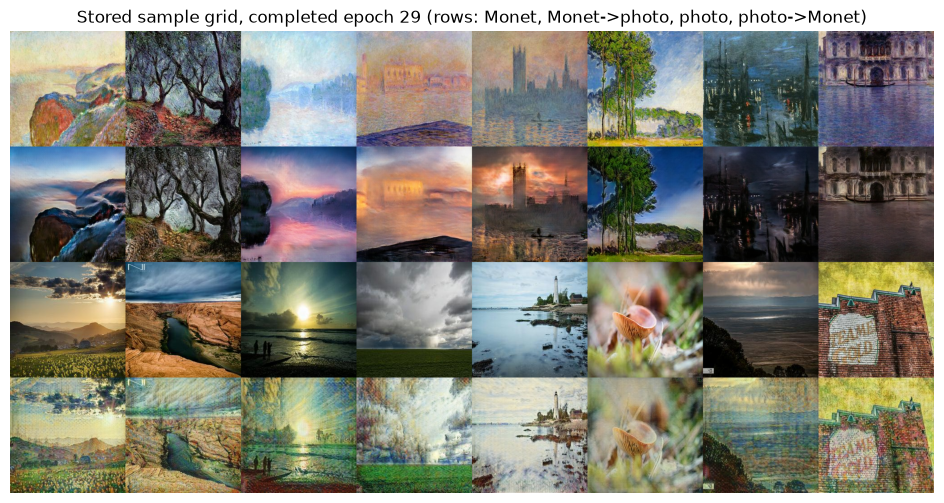

In [9]:
plt.figure(figsize=(12, 6)); plt.imshow(Image.open(K / "outputs/samples/samples_epoch029.png")); plt.axis("off")
plt.title("Stored sample grid, completed epoch 29 (rows: Monet, Monet->photo, photo, photo->Monet)"); plt.show()

## 10. Official FID / MiFID (course evaluator, N_EVAL = 300, JPEG q95)

In [10]:
off = json.load(open(K / "outputs/phase0/sweep/epoch_029/metrics.json"))
print("checkpoint SHA-256 in metrics.json:", off["checkpoint_sha256"], "| N_EVAL:", off["n_eval"])
assert off["checkpoint_sha256"] == EXPECTED_SHA
sub = pd.read_csv(K / "outputs/submission.csv")
tab = pd.DataFrame({"A2B (Monet->photo)": [off["fid_A2B"], off["mifid_A2B"]], "B2A (photo->Monet)": [off["fid_B2A"], off["mifid_B2A"]],
                    "average": [off["sub_fid"], off["sub_mifid"]]}, index=["FID", "MiFID"])
display(tab)
print("submission.csv:"); display(sub)
assert abs(sub.FID[0] - off["sub_fid"]) < 1e-12 and abs(sub.MiFID[0] - off["sub_mifid"]) < 1e-12
print("checkpoint-selection sweep (completed epochs 25-40, JPEG q95):")
sw = pd.read_csv(K / "outputs/phase0/phase0_summary.csv"); sw = sw[sw["format"] == "jpg_q95"]
display(sw[["epoch", "fid_A2B", "fid_B2A", "avg_fid", "avg_mifid", "projected_score"]].round(4).style.hide(axis="index"))
print("best average FID at completed epoch:", int(sw.loc[sw.avg_fid.idxmin(), "epoch"]), "| best average MiFID at completed epoch:", int(sw.loc[sw.avg_mifid.idxmin(), "epoch"]))
print("Note: selection used the same fixed in-domain reference set as the final score.")

checkpoint SHA-256 in metrics.json: d3124ab24a6f2201a03673cde5a416d04c78dd44985a3c7d590c48efc7e89d3c | N_EVAL: 300


,A2B (Monet->photo),B2A (photo->Monet),average
FID,95.008979,102.219476,98.614228
MiFID,0.413089,0.406872,0.409981


submission.csv:


,ID,FID,MiFID
0,1,98.614228,0.409981


checkpoint-selection sweep (completed epochs 25-40, JPEG q95):


epoch,fid_A2B,fid_B2A,avg_fid,avg_mifid,projected_score
25,98.446000,103.836200,101.141100,0.414400,-50.777700
26,103.390500,102.692200,103.041400,0.412800,-51.727100
27,103.090200,101.275000,102.182600,0.414600,-51.298600
28,101.882100,101.507800,101.694900,0.414700,-51.054800
29,95.009000,102.219500,98.614200,0.410000,-49.512100
30,102.031600,102.376500,102.204100,0.412600,-51.308300
31,98.375400,101.148800,99.762100,0.412100,-50.087100
32,95.987500,102.242200,99.114800,0.410200,-49.762500
33,102.295900,99.954600,101.125200,0.415100,-50.770200
34,95.603000,104.919900,100.261400,0.412800,-50.337100


best average FID at completed epoch: 29 | best average MiFID at completed epoch: 29
Note: selection used the same fixed in-domain reference set as the final score.


## 11-16. KID, precision/recall, cycle L1, LPIPS, content cosine
Evaluation set: **fixed in-domain set** (all 300 sorted Monet + first 300 sorted photos). The generators were trained on these image domains, so these numbers measure in-domain translation quality, not held-out generalization.

In [11]:
m = json.load(open(K / "outputs/final_eval_epoch029/metrics_final.json"))
assert m["checkpoint_sha256"] == EXPECTED_SHA
t = pd.DataFrame({
    "A2B (Monet->photo)": [f'{m["kid_A2B_subset_mean"]:.5f} +/- {m["kid_A2B_subset_std"]:.5f}', m["kid_A2B_full_sample"], m["precision_A2B"], m["recall_A2B"], m["density_A2B"], m["coverage_A2B"], m["content_cosine_A2B"]],
    "B2A (photo->Monet)": [f'{m["kid_B2A_subset_mean"]:.5f} +/- {m["kid_B2A_subset_std"]:.5f}', m["kid_B2A_full_sample"], m["precision_B2A"], m["recall_B2A"], m["density_B2A"], m["coverage_B2A"], m["content_cosine_B2A"]],
}, index=["KID (100 subsets of 100, seed 42)", "KID (full 300 vs 300)", "precision (k=3)", "recall (k=3)", "density (k=5, supplementary)", "coverage (k=5, supplementary)", "content cosine (input vs translation)"])
display(t)
c = pd.DataFrame({
    "A (Monet->photo->Monet)": [m["cycle_L1_A"], m["lpips_cycle_A"], m["lpips_direct_A"]],
    "B (photo->Monet->photo)": [m["cycle_L1_B"], m["lpips_cycle_B"], m["lpips_direct_B"]],
    "overall": [m["cycle_L1_overall"], m["lpips_cycle_overall"], m["lpips_direct_overall"]],
}, index=["cycle-reconstruction L1 ([0,1] pixels)", "LPIPS(alex): input vs cycle reconstruction", "LPIPS(alex): input vs direct translation (supplementary)"])
display(c)
print("content cosine overall:", round(m["content_cosine_overall"], 4))
print("protocols:"); [print(" -", k, ":", v) for k, v in m["protocol"].items()]

,A2B (Monet->photo),B2A (photo->Monet)
"KID (100 subsets of 100, seed 42)",0.01397 +/- 0.00217,0.00906 +/- 0.00179
KID (full 300 vs 300),0.014104,0.009135
precision (k=3),0.716667,0.4
recall (k=3),0.39,0.613333
"density (k=5, supplementary)",1.289333,0.392
"coverage (k=5, supplementary)",0.94,0.716667
content cosine (input vs translation),0.795972,0.770508


,A (Monet->photo->Monet),B (photo->Monet->photo),overall
"cycle-reconstruction L1 ([0,1] pixels)",0.042144,0.051256,0.046700
LPIPS(alex): input vs cycle reconstruction,0.241893,0.191196,0.216544
LPIPS(alex): input vs direct translation (supplementary),0.367758,0.390324,0.379041


content cosine overall: 0.7832
protocols:
 - evaluation_set : fixed in-domain set: all 300 sorted Monet + first 300 sorted photos (model trained on these domains; not held-out)
 - kid : unbiased MMD^2, polynomial kernel (x.y/d + 1)^3, d=2048, gamma=1/d, coef0=1, degree=3; 100 random subsets of 100 (no replacement) from 300 vs 300, RandomState(42); also full-sample 300 vs 300
 - precision_recall : Kynkaanniemi 2019 k-NN manifolds, k=3, Euclidean on 2048-d Inception features
 - density_coverage : Naeem 2020, k=5
 - cycle_L1 : mean |x - G_back(G_fwd(x))| on [0,1] pixel scale, raw tensors before JPEG
 - lpips : lpips 0.1.4, net=alex (v0.1), inputs in [-1,1], spatial mean
 - content_cosine : cos(Inception(input file), Inception(JPEG translation)), matched by sorted filename
 - inception : torchvision inception_v3 IMAGENET1K_V1, transform_input=False, fc=Identity, Resize299/CenterCrop299/ImageNet norm (course evaluator definition)


[None, None, None, None, None, None, None, None]

## 17. Human audit summary (30 blinded samples, 2 independent raters)

In [12]:
ha = pd.read_csv(K / "outputs/human_audit/human_audit_summary.csv")
display(ha.round(3).style.hide(axis="index"))
print("artifact_severity: 1 = no visible artifacts, 5 = severe artifacts (lower is better).")
print("Agreement is low (quadratic-weighted kappa 0.13 / 0.18 / -0.03): treat combined means as a blend of two rating scales.")

criterion,rater1_mean,rater1_sd,rater2_mean,rater2_sd,combined_mean,combined_sd,quadratic_weighted_kappa,exact_agreement_pct,mean_abs_difference
style_quality_1_to_5,4.000000,0.910000,2.967000,0.850000,3.483000,1.017000,0.130000,33.333000,1.100000
content_preservation_1_to_5,4.567000,0.568000,4.067000,0.944000,4.317000,0.813000,0.181000,50.000000,0.700000
artifact_severity_1_to_5,1.600000,0.621000,2.433000,1.040000,2.017000,0.948000,-0.025000,36.667000,1.033000


artifact_severity: 1 = no visible artifacts, 5 = severe artifacts (lower is better).
Agreement is low (quadratic-weighted kappa 0.13 / 0.18 / -0.03): treat combined means as a blend of two rating scales.


## 18. Training plots (from the unedited raw logs, completed epochs 1-29)

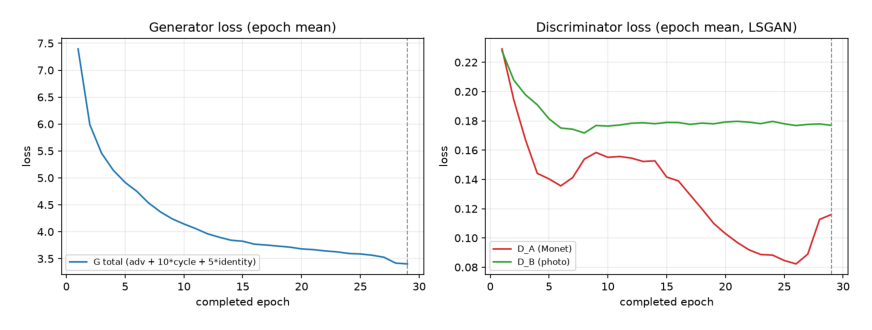

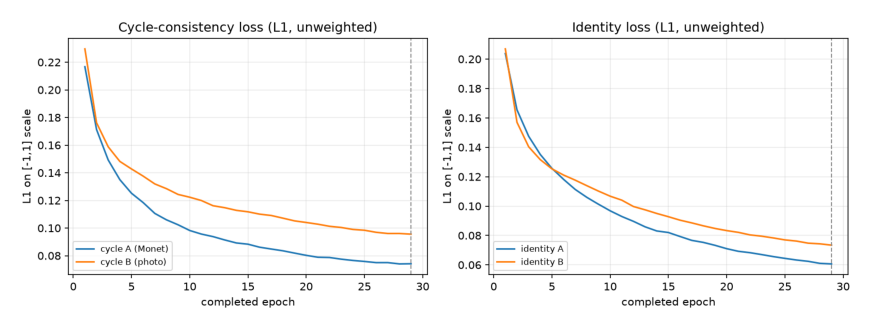

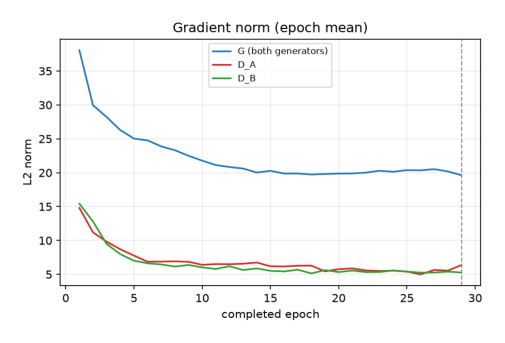

In [13]:
for f in ["generator_discriminator_losses.png", "cycle_identity_losses.png", "gradient_norms.png"]:
    plt.figure(figsize=(11, 4.2)); plt.imshow(Image.open(K / "outputs/plots" / f)); plt.axis("off"); plt.show()

## 19. Efficiency and stability metrics

In [14]:
s = json.load(open(K / "outputs/plots/training_summary.json"))
print(f'training time through completed epoch 29: {s["training_seconds_through_selected_epoch"]:,.1f} s ({s["training_seconds_through_selected_epoch"]/3600:.2f} h)')
print(f'throughput, epoch 29: {s["selected_epoch_images_per_second"]:.3f} iterations/s (one photo + one Monet image per iteration); mean over epochs 1-29: {s["mean_images_per_second_epochs_1_to_29"]:.3f}')
print(f'peak GPU memory (max over epochs): {s["peak_memory_bytes_max_over_epochs_1_to_29"]:,} bytes = {s["peak_memory_bytes_max_over_epochs_1_to_29"]/2**30:.2f} GiB')
print("recorded NaN/Inf abort events:", s["recorded_nan_inf_abort_events"])
print("epoch-29 means:", {k: round(v, 4) for k, v in s["selected_epoch_means"].items()})
ep = pd.read_csv(K / "outputs/plots/training_epoch_metrics.csv")
display(ep.iloc[[0, 8, 17, 25, 26, 27, 28]][["epoch", "G_total", "D_A", "D_B", "cycle_A", "cycle_B", "identity_A", "identity_B", "G_grad_norm"]].round(4).style.hide(axis="index"))

training time through completed epoch 29: 20,946.1 s (5.82 h)
throughput, epoch 29: 9.714 iterations/s (one photo + one Monet image per iteration); mean over epochs 1-29: 9.746
peak GPU memory (max over epochs): 2,894,273,536 bytes = 2.70 GiB
recorded NaN/Inf abort events: 0
epoch-29 means: {'G_total': 3.4024, 'D_A': 0.116, 'D_B': 0.177, 'cycle_A': 0.0742, 'cycle_B': 0.0956, 'identity_A': 0.0607, 'identity_B': 0.0734, 'G_grad_norm': 19.6311, 'D_A_grad_norm': 6.3712, 'D_B_grad_norm': 5.2732}


epoch,G_total,D_A,D_B,cycle_A,cycle_B,identity_A,identity_B,G_grad_norm
1,7.395300,0.229200,0.227700,0.216700,0.229600,0.203800,0.206900,38.075400
9,4.239600,0.158400,0.176800,0.102400,0.124300,0.101200,0.110200,22.495100
18,3.733300,0.119900,0.178500,0.083500,0.107200,0.075300,0.086600,19.733300
26,3.563500,0.082300,0.176800,0.075000,0.096900,0.063300,0.076200,20.347200
27,3.526300,0.089000,0.177600,0.075000,0.096100,0.062400,0.074800,20.518100
28,3.417500,0.112700,0.177900,0.074100,0.096100,0.061000,0.074300,20.182100
29,3.402400,0.116000,0.177000,0.074200,0.095600,0.060700,0.073400,19.631100


## 20. Kaggle result and evidence

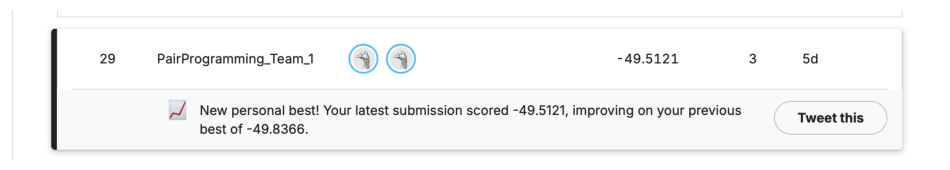

submission.csv: {'ID': 1.0, 'FID': 98.61422779159996, 'MiFID': 0.4099805057048797}
calculated class metric -(FID+MiFID)/2 = -49.512104  (screenshot shows -49.5121, team PairProgramming_Team_1, rank 29)


In [15]:
plt.figure(figsize=(12, 2.2)); plt.imshow(Image.open(next((K / "outputs/kaggle").glob("*.png")))); plt.axis("off"); plt.show()
sub = pd.read_csv(K / "outputs/submission.csv")
calc = -(sub.FID[0] + sub.MiFID[0]) / 2
print("submission.csv:", sub.iloc[0].to_dict())
print(f"calculated class metric -(FID+MiFID)/2 = {calc:.6f}  (screenshot shows -49.5121, team PairProgramming_Team_1, rank 29)")
assert round(calc, 4) == -49.5121

## 21. Limitations
- **In-domain evaluation:** the 300 + 300 evaluation images belong to the training domains, and the checkpoint was selected using the same reference set, so no held-out generalization claim is made.
- **Small evaluation sets:** with 300 images per set, FID is biased and KID, precision and recall carry material sampling uncertainty.
- **Training length:** training was stopped at epoch 40 of a planned 200; the selected checkpoint is from the constant-learning-rate phase.
- **Human audit:** two raters, 30 samples, low inter-rater agreement.
- **Kaggle rank** is a team-level snapshot at the time of the screenshot.

## 22. Final summary

In [16]:
summary = pd.DataFrame([
    ("checkpoint", "epoch_28.pt (completed epoch 29), SHA-256 d3124ab2...c89d3c"),
    ("parameters", "28,285,832"),
    ("official FID (A2B / B2A / avg)", f'{off["fid_A2B"]:.3f} / {off["fid_B2A"]:.3f} / {off["sub_fid"]:.3f}'),
    ("official MiFID (A2B / B2A / avg)", f'{off["mifid_A2B"]:.4f} / {off["mifid_B2A"]:.4f} / {off["sub_mifid"]:.4f}'),
    ("KID (A2B / B2A)", f'{m["kid_A2B_subset_mean"]:.4f} / {m["kid_B2A_subset_mean"]:.4f}'),
    ("precision / recall A2B", f'{m["precision_A2B"]:.3f} / {m["recall_A2B"]:.3f}'),
    ("precision / recall B2A", f'{m["precision_B2A"]:.3f} / {m["recall_B2A"]:.3f}'),
    ("cycle L1 (A / B)", f'{m["cycle_L1_A"]:.4f} / {m["cycle_L1_B"]:.4f}'),
    ("LPIPS cycle (A / B)", f'{m["lpips_cycle_A"]:.4f} / {m["lpips_cycle_B"]:.4f}'),
    ("content cosine (A2B / B2A)", f'{m["content_cosine_A2B"]:.4f} / {m["content_cosine_B2A"]:.4f}'),
    ("human audit combined means (style / content / artifacts)", " / ".join(f"{v:.2f}" for v in ha.combined_mean)),
    ("training time / peak memory", f'{s["training_seconds_through_selected_epoch"]/3600:.2f} h / {s["peak_memory_bytes_max_over_epochs_1_to_29"]/2**30:.2f} GiB'),
    ("Kaggle (team leaderboard screenshot)", "rank 29, score -49.5121"),
], columns=["item", "value"])
summary.style.hide(axis="index")

item,value
checkpoint,"epoch_28.pt (completed epoch 29), SHA-256 d3124ab2...c89d3c"
parameters,"28,285,832"
official FID (A2B / B2A / avg),95.009 / 102.219 / 98.614
official MiFID (A2B / B2A / avg),0.4131 / 0.4069 / 0.4100
KID (A2B / B2A),0.0140 / 0.0091
precision / recall A2B,0.717 / 0.390
precision / recall B2A,0.400 / 0.613
cycle L1 (A / B),0.0421 / 0.0513
LPIPS cycle (A / B),0.2419 / 0.1912
content cosine (A2B / B2A),0.7960 / 0.7705
